<div style="box-sizing:border-box;max-width:100%;margin:0 0 8px;padding:4px 0;color:inherit;line-height:1.35;"><img src="https://thetahat.ru/images/logo_thetahat.png" alt="ThetaHat" style="display:block!important;width:52px!important;max-width:52px!important;height:auto!important;margin:0 0 9px 0!important;padding:0!important;"><div style="display:flex;align-items:center;justify-content:space-between;flex-wrap:wrap;gap:8px 12px;"><span style="min-width:0;color:inherit;font-size:12px;font-weight:700;letter-spacing:0.055em;text-transform:uppercase;"><a href="https://thetahat.ru/courses/ysda-group" style="color:inherit;text-decoration:none;">Школа анализа данных</a>&nbsp;·&nbsp;Машинное обучение</span></div></div>

<h2><span style="display:block;box-sizing:border-box;max-width:100%;padding:16px 22px 17px;border-radius:14px;background:linear-gradient(135deg,#D4470E 0%,#C7324E 50%,#B316B8 100%);color:#FFFFFF;line-height:1.15;font-weight:500;">Лекция. Логистическая регрессия</span></h2>

В этом ноутбуке мы рассмотрим пример построения модели логистической регрессии для бинарной классификации и предварительной обработки данных. Логистическая регрессия является одним из методов классификации и используется для предсказания категориальных исходов.



In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings

import scipy.stats as sps
from typing import Any, Tuple, List

from sklearn.datasets import fetch_openml, make_blobs
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.multiclass import OneVsRestClassifier, OneVsOneClassifier
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.base import BaseEstimator
from sklearn.dummy import DummyClassifier

from notebook_logreg_tools import (
    measure_time,
    save_model_and_get_size,
    plot_compare_model_performance,
    ModelBenchmark,
    visualize_data,
    plot_logreg_coefficients,
    plot_logit_linearity_check,
    plot_decision_boundary,
)

# Настройки отображения
sns.set(style="darkgrid", font_scale=1.2, palette="Set2")
RANDOM_STATE = 7  # фиксируем зерно случайности
pd.options.mode.chained_assignment = None
warnings.filterwarnings("ignore")

### <span style="display:inline-block;padding:2px 8px;border-radius:999px;background:linear-gradient(135deg, #C7480B 0%, #B52D59 54%, #A617B3 100%);color:#FFFFFF;font-size:0.78em;vertical-align:0.08em;">1</span> <span style="color:inherit;">Введение</span>

#### <span style="display:inline-block;padding:2px 8px;border-radius:999px;background:linear-gradient(135deg, #C7480B 0%, #B52D59 54%, #A617B3 100%);color:#FFFFFF;font-size:0.78em;vertical-align:0.08em;">1.1</span> <span style="color:inherit;">Данные</span>

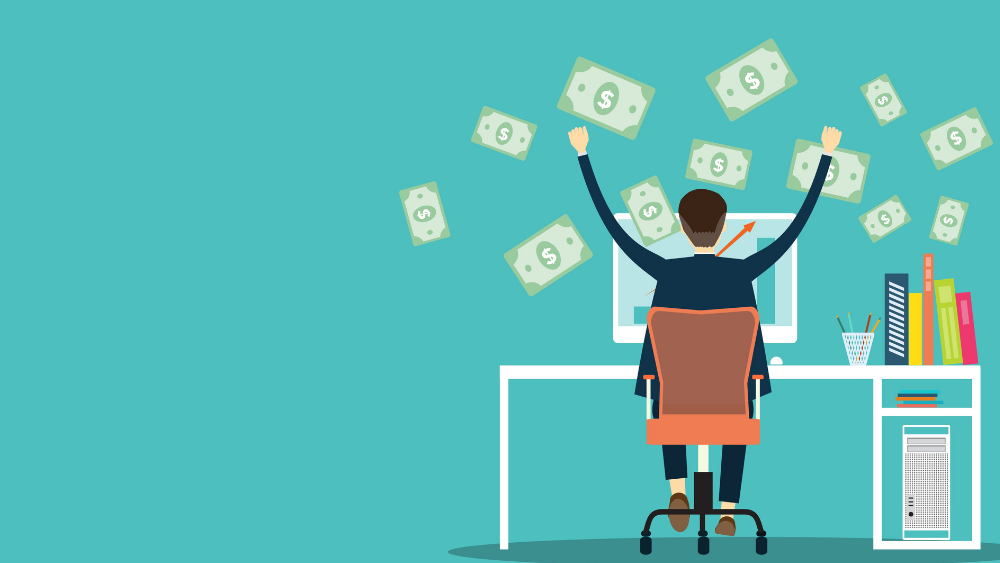

[Adult Income Dataset](https://archive.ics.uci.edu/ml/datasets/adult) — датасет содержит информацию из переписи населения США 1994 года и широко применяется для задач классификации в машинном обучении. Основная цель — предсказать, зарабатывает ли человек более **50K** долларов в год на основе его социально-демографических характеристик.  

Набор данных включает следующие признаки:  

* `age` — возраст респондента  
* `workclass` — класс занятости (например, государственный сектор, частный бизнес, самозанятый)  
* `fnlwgt` — финальный вес (корректирующий коэффициент для репрезентативности выборки)  
* `education` — уровень образования (например, Bachelors, HS-grad)  
* `education-num` — количество лет обучения  
* `marital-status` — семейное положение  
* `occupation` — род занятий (например, Tech-support, Sales)  
* `relationship` — семейные роли (например, husband, wife, not-in-family)  
* `race` — раса респондента  
* `sex` — пол  
* `capital-gain` — капитализация дохода (прибыль от инвестиций)  
* `capital-loss` — капитализация убытков (убытки от инвестиций)  
* `hours-per-week` — количество рабочих часов в неделю  
* `native-country` — страна происхождения  
* `income` — целевая переменная: доход больше или меньше **50K**


In [2]:
data = fetch_openml("adult", version=2, as_frame=True)
X_data, y_data = data.data, data.target
y_data = (y_data == ">50K").astype(int)

X_data.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States
4,18,NaN,103497,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States


In [3]:
X_data.shape

(48842, 14)

Разделим данные на трейн и тест.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X_data, y_data, test_size=0.2, random_state=RANDOM_STATE
)

Посмотрим, есть ли в данных пропуски.

In [5]:
X_train.isna().sum()

age                  0
workclass         2258
fnlwgt               0
education            0
education-num        0
marital-status       0
occupation        2264
relationship         0
race                 0
sex                  0
capital-gain         0
capital-loss         0
hours-per-week       0
native-country     665
dtype: int64

Для начала удалим столбцы, содеражащие пропуски. Более серьезной обработкой пропусков займемся далее.

In [6]:
X_train_drop = X_train.drop(columns=["native-country", "occupation", "workclass"])
X_test_drop = X_test.drop(columns=["native-country", "occupation", "workclass"])

#### <span style="display:inline-block;padding:2px 8px;border-radius:999px;background:linear-gradient(135deg, #C7480B 0%, #B52D59 54%, #A617B3 100%);color:#FFFFFF;font-size:0.78em;vertical-align:0.08em;">1.2</span> <span style="color:inherit;">Бейзлайн модели</span>

In [7]:
dummy_model = DummyClassifier(strategy="most_frequent")
dummy_model.fit(X_train_drop, y_train)

y_pred = dummy_model.predict(X_test_drop)

acc = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc:.4f}")

Accuracy: 0.7635


<div style="box-sizing:border-box;max-width:100%;margin:14px 0 0;padding:0;border:1px solid rgba(199,50,78,0.20);border-bottom:0;border-radius:12px 12px 0 0;overflow:hidden;color:inherit;"><span style="display:inline-block;padding:4px 11px;border-radius:4px 12px 12px 4px;background:linear-gradient(135deg,#D4470E,#C7324E,#B316B8);color:white;font-size:10.5px;font-weight:800;letter-spacing:0.06em;text-transform:uppercase;white-space:nowrap;">Вопрос</span></div>

<div style="box-sizing:border-box;max-width:100%;padding:10px 14px 13px;border-left:1px solid rgba(199,50,78,0.20);border-right:1px solid rgba(199,50,78,0.20);border-bottom:1px solid rgba(199,50,78,0.20);border-radius:0 0 12px 12px;margin-bottom:8px;">


О чем может говорить столь высокое качество предсказанием самым частым классом?


</div>

<details style="box-sizing:border-box;max-width:100%;margin:0 0 18px;padding:8px 14px 10px;border:1px solid rgba(199,50,78,0.20);border-radius:10px;color:inherit;">

<summary style="cursor:pointer;color:inherit;font-size:13px;font-weight:750;text-decoration:underline;text-decoration-color:#C7324E;text-decoration-thickness:1.5px;text-underline-offset:3px;">Показать ответ</summary>

О сильном дисбалансе классов в таргете.

</details><br/>



При выборе модели важно учитывать не только качество, но и производительность.  
Часто бывает, что модель с немного худшими метриками работает быстрее и требует меньше ресурсов. Это делает её более практичной.  

Будем сравнивать модели с точки зрения следующих параметров:

- время обучения  
- время предсказания  
- объём памяти, занимаемый обученной моделью  
- качество предсказаний по выбранной метрике

In [8]:
def evaluate_model_performance(
    model: BaseEstimator,
    X_train: np.ndarray,
    X_test: np.ndarray,
    y_train: np.ndarray,
    y_test: np.ndarray,
    n_iter: int = 7,
) -> Tuple[List[float], List[float], List[float], List[float]]:
    """
    Функция для оценки модели в задаче регресии.

    Параметры:
    - model: необученная модель
    - X_train: тренировочные данные (признаки)
    - y_train: тренировочные данные (целевая переменная)
    - X_test: тестовые данные (признаки)
    - y_test: тестовые данные (целевая переменная)
    - n_iter: число интераций замеров параметров для оценки среднего

    Возвращает:
    - fit_times: время обучения
    - prediсt_times: время предсказания
    - sizes: память занимаемая обученной моделью
    - metrics: качество по метрике Accuracy
    """
    fit_times = []
    predict_times = []
    sizes = []
    metrics = []

    for _ in range(n_iter):
        # Замер времени обучения
        fit_time, _ = measure_time(model.fit)(X_train, y_train)
        fit_times.append(fit_time)

        # Замер времени предсказания
        predict_time, y_pred = measure_time(model.predict)(X_test)
        predict_times.append(predict_time)

        # Сохранение модели и получение размера
        model_size_kb = save_model_and_get_size(model)
        sizes.append(model_size_kb)

        # Рассчет метрики
        metrics.append(accuracy_score(y_test, y_pred))

    return fit_times, predict_times, sizes, metrics

Так будем смотреть на таблицу с применением стиля

In [9]:
benchmark = ModelBenchmark(evaluate_model_performance=evaluate_model_performance)
benchmark.show_table()

,Model,Fit time (s),Predict time (s),Memory (KB),Accuracy


Посмотрим на производительнось бейзлайна.

In [10]:
benchmark.add_model(dummy_model, "Baseline", X_train, X_test, y_train, y_test)
display(benchmark.show_table())

Модель 'Baseline' успешно добавлена.


,Model,Fit time (s),Predict time (s),Memory (KB),Accuracy
0,Baseline,0.001311,0.000130,0.991211,0.763538


#### <span style="display:inline-block;padding:2px 8px;border-radius:999px;background:linear-gradient(135deg, #C7480B 0%, #B52D59 54%, #A617B3 100%);color:#FFFFFF;font-size:0.78em;vertical-align:0.08em;">1.3</span> <span style="color:inherit;">Проблемы kNN</span>

Попробуем сначала обучить модель kNN и оценим ее качество.

---

Посчитать **ошибку предсказания** можно разными способами. Рассмотрим одну из основных метрик.

>**Точность (Accuracy)** \
>Точность определяет общую долю правильно классифицированных случаев:
>
> $$\text{Accuracy} =\frac{1}{n} \sum_{i=1}^{n} I\left\{Y_i = \widehat{Y}_i\right\}$$

Для обучения kNN необходимо обработать признаки. Разобьем признаки на категориальные и числовые:
* Числовые &mdash; стандартизируем
* Категориальные &mdash; закодируем с помощью  <a target="_blank" href="https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OneHotEncoder.html">`OneHotEncoder`</a>.

In [11]:
cat_features = ["education", "marital-status", "relationship", "race", "sex"]
num_features = ["age", "fnlwgt", "education-num", "capital-gain", "capital-loss", "hours-per-week"]

 Чтобы применять разные преобразования к разным группам столбцов, используется класс [`ColumnTransformer`](https://scikit-learn.org/stable/modules/generated/sklearn.compose.ColumnTransformer.html).

`ColumnTransformer` &mdash; это трансформер `sklearn`, который позволяет:
* разделить признаки на группы
* задать свои преобразования для каждой группы признаков
* автоматически применить соответствующие преобразования к нужным столбцам
* объединить результаты в единый итоговый массив признаков

Он принимает список кортежей вида `(name, transformer, columns)`:
* `name` &mdash; имя группы преобразований (произвольная строка)
* `transformer` &mdash; преобразование которое будет применёно
* `columns` &mdash; список столбцов, к которым применяется данный `transformer`

In [12]:
preprocessor = ColumnTransformer(
    [
        (
            "num",
            StandardScaler(),
            num_features,
        ),
        (
            "cat",
            OneHotEncoder(drop="first", sparse_output=False),
            cat_features,
        ),
    ]
)

X_train_processed = preprocessor.fit_transform(X_train_drop)
X_test_processed = preprocessor.transform(X_test_drop)

Обучим kNN

In [13]:
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_processed, y_train)

y_pred = knn_model.predict(X_test_processed)

acc = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc:.4f}")

Accuracy: 0.8241


Мы получили достаточно хорошую точность предсказаний, однако у kNN могут возникнуть проблемы со скоростью и памятью.

---

**Особенности kNN**

- *Память*: kNN хранит всю выборку, следовательно при большом числе объектов модель становится «тяжёлой».  

- *Время предсказания*: для нового объекта kNN сравнивает его со всеми в обучающем наборе, и значит, работает медленно на больших данных.  

- *Интерпретация*: модель даёт только «ответ большинства соседей», а влияние отдельного признака на вероятность предсказания понять сложно.  

  У модели нет коэффициентов, показывающих, насколько сильно и в какую сторону конкретный признак влияет на результат. Изменение признака меняет список соседей, а не результат напрямую, поэтому сложно предсказать, как сдвиг входных данных повлияет на прогноз.

Это делает kNN мало пригодным для задач, где важна скорость и интерпретируемость.

Посмотрим на производительнось kNN.

In [14]:
benchmark.add_model(knn_model, "kNN", X_train_processed, X_test_processed, y_train, y_test)

display(benchmark.show_table())

Модель 'kNN' успешно добавлена.


,Model,Fit time (s),Predict time (s),Memory (KB),Accuracy
0,Baseline,0.001311,0.000130,0.991211,0.763538
1,kNN,0.002834,1.158658,11600.589844,0.824138


1. kNN обучается очень быстро. Это ожидаемо, так как kNN на этапе `fit` просто сохраняет тренировочную выборку и не строит сложных моделей.  
2. Предсказание очень медленное, потому что для каждого тестового объекта kNN сравнивает его со всеми объектами тренировочной выборки.  
3. Модель хранит всю тренировочную выборку, поэтому занимает много памяти. При росте количества объектов и признаков память будет расти линейно.
4. kNN показывает достаточно хорошую точность, но следует учитывать предыдущие моменты.

**Вывод:** kNN подходит для задач с небольшими выборками и нестрогими требованиями к скорости предсказаний. Для больших данных и там, где важна интерпретируемость, лучше рассмотреть другие модели.


✍ **Теперь перейдём к лекционной части и узнаем, как работает логистическая регресия.**

### <span style="display:inline-block;padding:2px 8px;border-radius:999px;background:linear-gradient(135deg, #C7480B 0%, #B52D59 54%, #A617B3 100%);color:#FFFFFF;font-size:0.78em;vertical-align:0.08em;">2</span> <span style="color:inherit;">Логистическая регрессия</span>

#### <span style="display:inline-block;padding:2px 8px;border-radius:999px;background:linear-gradient(135deg, #C7480B 0%, #B52D59 54%, #A617B3 100%);color:#FFFFFF;font-size:0.78em;vertical-align:0.08em;">2.1</span> <span style="color:inherit;">Логистическая регрессия на искусственных данных</span>


Для базового понимания лог регрессии рассмотрим искусственные данные с бинарным признаком из `sklearn.datasets`. Будем генерировать выборку из двух нормальных распределений.

In [15]:
def generate_data(n_samples):
    """
    Генерирует выборку из двух нормальных распределений и возвращает их вместе с метками.

    Параметры:
    n_samples (int): Общее количество элементов в выборке. Количество примеров каждого класса
                     будет равно половине от n_samples.

    Возвращает:
    X (ndarray): Массив данных с признаками. Имеет форму (n_samples, 1).
    y (ndarray): Массив меток классов. Содержит 0 для первого класса и 1 для второго.
    """

    # Генерация данных для первого класса (X0, y0)
    X0 = np.random.normal(3, 2, int(n_samples / 2))
    y0 = np.zeros(X0.shape[0])

    # Генерация данных для второго класса (X1, y1)
    X1 = np.random.normal(8, 2, int(n_samples / 2))
    y1 = np.ones(X1.shape[0])

    # Объединение данных и меток
    X = np.hstack((X0, X1)).reshape(-1, 1)
    y = np.concatenate((y0, y1))

    return X, y

Сгенерируем искусственные данные.

In [16]:
n_samples = 300  # Размер выборки
X, y = generate_data(n_samples)

Визуализируем распределение значений в классах.

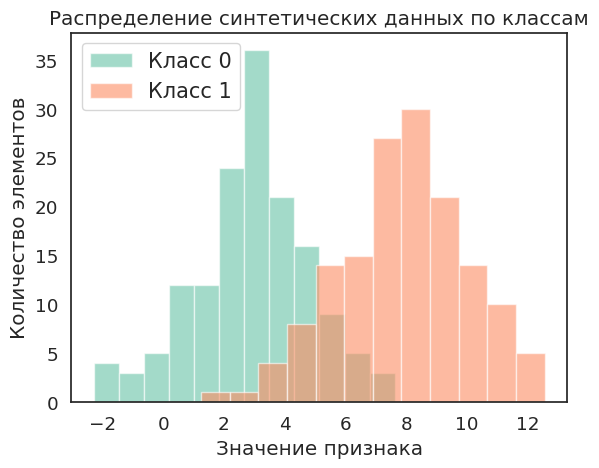

In [17]:
with sns.axes_style("white"):
    visualize_data(X, y)

Мы ищем модель, которая одновременно:

* простая по структуре
* интерпретируемая (можно объяснить, как признаки влияют на предсказания)
* даёт достаточно высокое качество

Для регрессии таким кандидатом была линейная регрессия, а для классификации естественным аналогом становится логистическая регрессия.


Обучим модель **логистической регрессии** с помощью класса <a target="_blank" href="https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html">`LogisticRegression`</a>. Рассмотрим, как работают методы `fit`, `predict` и `predict_proba` для логистической регрессии в случае бинарной классификации

---
>**Важные аргументы конструктора:**
>* `fit_intercept` &mdash; нужно ли включать в модель свободный член. В случае `fit_intercept=True` модели не нужно передавать признак из всех единиц для того, чтобы она оценивала свободный член. По умолчанию `fit_intercept=True`.
>* `solver` &mdash; метод оптимизации для поиска оценки коэффициентов. По умолчанию `solver="lbfgs"`.
>* `max_iter` &mdash; количество итераций метода оптимизации. По умолчанию `max_iter=100`.
>* Есть также важные параметры регуляризации `penalty` и `C`, но про регуляризации мы будем говорить на следующем занятии.
>
> **Основные методы класса:**
>
> - **метод `fit`**
>
>     Метод `fit(X, y)` оценивает оптимальные значения параметров модели $\theta$, численно решая следующую задачу оптимизации: $$\min_{\theta} \sum_{i=1}^{n} \left[ - Y_i \log\left(\sigma(x_i^T \theta)\right) - (1-Y_i) \log\left(1-\sigma(x_i^T \theta)\right) \right]$$ где $\sigma(z)$ — логистическая сигмоида, которая преобразует линейную комбинацию признаков в вероятность:
>$$\sigma(z) = \frac{1}{1 + \exp(-z)}$$
>
>
> * **метод `predict_proba`**
>
>     Метод `predict_proba(X)` оценивает вероятности принадлежности к классу 1 по формуле:
>
>     $$\widehat{p}({x}) = \sigma\left(x^T \widehat{\theta}\right) = \frac{1}{1 + \exp\left(-x^T \widehat{\theta}\right)}$$
>      Для каждого объекта из `X` возвращает два числа &mdash; оценки вероятностей классов 0 и 1. Важно помнить, что они не являются истинными вероятностями, это только *оценки* вероятностей.
>
>
> * **метод `predict`**
>
>     Метод `predict(X)` переводит эти оценки вероятностей, полученные методом `predict_proba(X)`, в бинарные классы («0» или «1») с использованием порога, обычно равного 0.5. То есть: $$\widehat{y}(x) = \begin{cases}
1, & \text{если } \widehat{p}(x) \geq 0.5 \\
0, & \text{если } \widehat{p}(x) < 0.5
\end{cases}$$ Эти шаги позволяют логистической регрессии моделировать вероятность принадлежности к определенному классу и принимать решение о классификации на этом основании.

In [18]:
# Логистическая регрессия
model = LogisticRegression()
model.fit(X, y)

# Предсказание вероятностей
X_range = np.linspace(X.min() - 1, X.max() + 1, 500).reshape(-1, 1)
probabilities = model.predict_proba(X_range)[:, 1]

Визуализируем полученные вероятности.

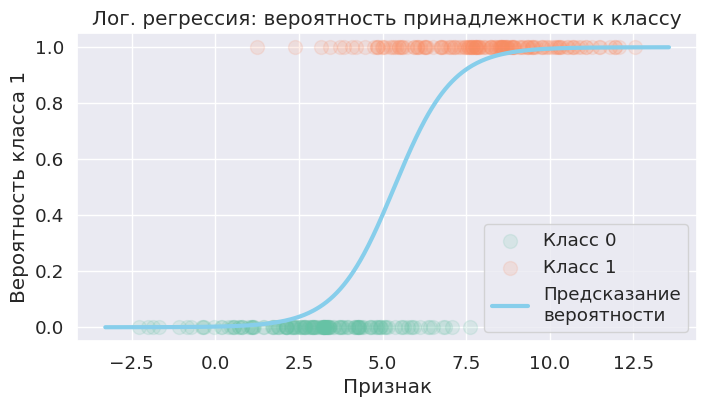

In [19]:
plt.figure(figsize=(8, 4))
plt.scatter(X[y == 0], np.zeros_like(X[y == 0]), s=100, label="Класс 0", alpha=0.15)
plt.scatter(X[y == 1], np.ones_like(X[y == 1]), s=100, label="Класс 1", alpha=0.15)
plt.plot(X_range, probabilities, label="Предсказание\nвероятности", c="skyblue", linewidth=3)
plt.title("Лог. регрессия: вероятность принадлежности к классу")
plt.xlabel("Признак")
plt.ylabel("Вероятность класса 1")
plt.legend()
plt.show()

Видно, что
* при малых значениях признака модель уверенно относит объекты к классу 0, а при больших — к классу 1.
* в области, где классы пересекаются вероятность принадлежности к классу 1 равна примерно 0.5 — это граница принятия решения.
* чем дальше объект от границы, тем выше уверенность модели.

#### <span style="display:inline-block;padding:2px 8px;border-radius:999px;background:linear-gradient(135deg, #C7480B 0%, #B52D59 54%, #A617B3 100%);color:#FFFFFF;font-size:0.78em;vertical-align:0.08em;">2.2</span> <span style="color:inherit;">Логистическая регрессия на реальных данных</span>

Вернемся к исходным данным и попробуем приминить полученные знания.


In [20]:
lr_model = LogisticRegression()
lr_model.fit(X_train_processed, y_train)

y_pred = lr_model.predict(X_test_processed)

acc = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc:.4f}")

Accuracy: 0.8347


Метрика точности логистической регрессии оказалась чуть выше, чем у kNN. Проанализируем производительность обеих моделей и сравним их.

In [21]:
benchmark.add_model(
    lr_model, "Logistic Regression", X_train_processed, X_test_processed, y_train, y_test
)

display(benchmark.show_table())

Модель 'Logistic Regression' успешно добавлена.


,Model,Fit time (s),Predict time (s),Memory (KB),Accuracy
0,Baseline,0.001311,0.000130,0.991211,0.763538
1,kNN,0.002834,1.158658,11600.589844,0.824138
2,Logistic Regression,1.321128,0.002030,1.139648,0.834681


1. **Время обучения:**  
    - Несмотря на то, что логистическая регрессия требует больше времени на обучение, менее секунды – все еще очень быстро.

2. **Время предсказания:**
    - Логистическая регрессия делает предсказания почти мгновенно, потому что использует вычисленные коэффициенты для прямого расчёта вероятностей классов, что требует лишь матричных операций.

    - kNN для каждого тестового объекта сравнивает его со всеми объектами тренировочной выборки, что делает время предсказание линейным по размеру выборки.

3. **Память:**
    - kNN хранит всю тренировочную выборку, поэтому объём памяти растёт линейно с числом объектов и признаков.

    - Логистическая регрессия хранит только коэффициенты модели — веса для каждого признака и свободный член. Это означает, что объем памяти зависит только от количества признаков, что делает модель компактной.

4. **Интерпретируемость:**
    - В отличие от kNN, коэффициенты логистической регрессии имеют прямую интерпретацию (будет показано позже).

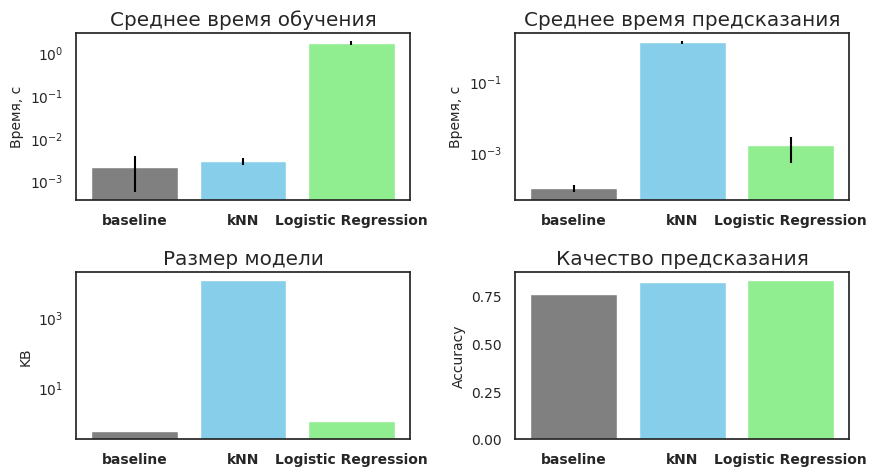

In [22]:
models = [DummyClassifier(), KNeighborsClassifier(n_neighbors=5), LogisticRegression()]
labels = ["baseline", "kNN", "Logistic Regression"]
colors = ["grey", "skyblue", "lightgreen"]

plot_compare_model_performance(
    models,
    X_train_processed,
    X_test_processed,
    y_train,
    y_test,
    labels,
    colors,
    evaluate_model_performance=evaluate_model_performance,
)

#### <span style="display:inline-block;padding:2px 8px;border-radius:999px;background:linear-gradient(135deg, #C7480B 0%, #B52D59 54%, #A617B3 100%);color:#FFFFFF;font-size:0.78em;vertical-align:0.08em;">2.3</span> <span style="color:inherit;">Улучшаем предсказания модели</span>

Поробуем улучшить предсказания модели. В самом начале мы выкинули столбцы содеражащие пропуски, при этом потеряв часть информации. Попробуем обработать пропуски в данных так, чтобы сохранить всю нужную информацию.




Будем **обрабатывать пропуски** следующим образом:

- Для числовых признаков: заполнение медианными значениями
- Для категориальных признаков: заполнение наиболее частыми значениями

Для подобных преобразований удобно воспользоваться трансформером [`sklearn.SimpleImputer`](https://scikit-learn.org/stable/modules/generated/sklearn.impute.SimpleImputer.html) &mdash; это трансформер, предназначенный для заполнения пропущенных значений в данных.

Он работает следующим образом:
1. вычисляет статистику по обучающей выборке (например, медиану или наиболее частое значение)
2. затем использует эти значения для заполнения пропусков как в обучающей, так и в тестовой выборке

Параметр `strategy` определяет способ заполнения:
*  `median` &mdash; используется медиана признака, подходит для числовых признаков
*  `most_frequent` &mdash; используется наиболее часто встречающееся значение, подходит для категориальных признаков

**❗️Важно: значения для заполнения вычисляются только на обучающей выборке при вызове метода `fit()`. Метод `transform()` применяет уже вычисленные значения без пересчёта, что предотвращает утечку данных.**

In [23]:
cat_features = [
    "education",
    "marital-status",
    "relationship",
    "race",
    "sex",
    "workclass",
    "native-country",
    "occupation",
]
num_features = ["age", "fnlwgt", "education-num", "capital-gain", "capital-loss", "hours-per-week"]

Помимо этого мы также
* стандартизируем числовые признаки,
* закодируем категориальные признаки с помощью  <a target="_blank" href="https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OneHotEncoder.html">`OneHotEncoder`</a>.

>Заметим, что у нас вырисовывается некий **пайплайн**, т.е. шаблонный алгоритм:
>1.  Сначала мы заполняем пропуски
>2.  Затем стандартизируем числовые признаки и применяем OneHot для категориальных признаков
>
>Эти шаги неразделимы, поэтому удобно поместить их в один "контейнер" и работать с ним как с обычной моделью. Для этого в `sklearn` придумали класс [`Pipeline`](https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.Pipeline.html):
>
>Внутри `Pipeline` представляет собой список кортежей `(name, transformer)`, где:
>
>* `name` &mdash; произвольная строка-идентификатор шага (используется для доступа к параметрам и отладки)
>* `transformer` &mdash; объект с методами `fit()` и `transform()` (или `fit_transform()`)
>
>Это гарантирует, что правило **"fit на train"** будет соблюдено автоматически для всех шагов сразу.



In [24]:
preprocessor = ColumnTransformer(
    [
        (
            "num",
            Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())]),
            num_features,
        ),
        (
            "cat",
            Pipeline(
                [
                    ("imputer", SimpleImputer(strategy="most_frequent")),
                    ("onehot", OneHotEncoder(drop="first", sparse_output=False)),
                ]
            ),
            cat_features,
        ),
    ]
)

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

In [25]:
benchmark.add_model(
    lr_model, "LR NaN processed", X_train_processed, X_test_processed, y_train, y_test
)

display(benchmark.show_table())

Модель 'LR NaN processed' успешно добавлена.


,Model,Fit time (s),Predict time (s),Memory (KB),Accuracy
0,Baseline,0.001311,0.000130,0.991211,0.763538
1,kNN,0.002834,1.158658,11600.589844,0.824138
2,Logistic Regression,1.321128,0.002030,1.139648,0.834681
3,LR NaN processed,2.390156,0.008578,1.608398,0.846351


Ура! Нам удалось поднять качество модели.

### <span style="display:inline-block;padding:2px 8px;border-radius:999px;background:linear-gradient(135deg, #C7480B 0%, #B52D59 54%, #A617B3 100%);color:#FFFFFF;font-size:0.78em;vertical-align:0.08em;">3</span> <span style="color:inherit;">Интерпретация значений коэффициентов</span>

Все еще остался вопрос по интерпретации. Вспомним что, в линейной регрессии коэффициенты характеризуют величину и направление влияния каждого признака на целевую переменную. Для логичстической регресии ситуация похожая.

1. **Знак коэффициента**
   - Положительный коэффициент указывает на то, что с увеличением значения признака шансы первого класса увеличиваются при прочих равных условиях.
   - Отрицательный коэффициент означает, что с увеличением значения признака шансы на положительный исход (первый признак) уменьшаются при прочих равных условиях.
2. **Значение коэффициента**
- Пусть для некоторого объекта полученные вероятности классов 0 и 1 соответственно равны $(1 - p_0)$ и $p_0$. Тогда для логита выполняется следующее соотношение
   $$
   \log\left(\frac{p_0}{1-p_0}\right) = \theta_0 + \theta_1  x_1 + \theta_2  x_2 + \ldots + \theta_d  x_d
   $$
- Пусть $p_1$ &mdash; вероятность класса 1 при увеличении значения признака $x_j$ на 1 и неизменных значениях всех остальных признаков. Тогда соответствующий логит можно выразить следующим образом:
   $$
   \log\left(\frac{p_1}{1-p_1}\right) = \log\left(\frac{p_0}{1-p_0}\right) + \theta_j
   $$
  
Выразим отношения вероятностей
$$
\left. \frac{p_1}{1-p_1} \right/ \frac{p_0}{1-p_0} = \exp\left(\theta_j\right)
$$
    
Получаем следующий вывод **об интерпретации коэффициентов линейной регрессии**. При изменении признака $x_j$ на 1 и *фиксированных значениях остальных признаков* отношение вероятности класса 1 к вероятности класса 0 изменяется в $\exp\left(\theta_j\right)$ раз.

Данную интерпретацию можно упростить, если рассмотреть случай *малых значений* $p_0$ и $p_1$. В таком случае $1-p_0 \approx 1$ и $1-p_1 \approx 1$, соответственно получаем
$$
\exp\left(\theta_j\right) \approx \frac{p_1}{p_0},
$$
$$
p_1 \approx p_0 \exp\left(\theta_j\right).
$$
Тем самым, интерпретация упрощается: при изменении признака $x_j$ на 1 и *фиксированных значениях остальных признаков* вероятность класса 1 (если она мала) увеличивается примерно в $\exp\left(\theta_j\right)$ раз.

Читателям с серьёзным техническим образованием может показаться странным такое упрощение. Однако на практике оказывается очень полезным объяснять полученные модели простыми словами. Этого часто требуют заказчики, которые хотят понимать принципы работы модели, но им сложно воспринимать сложные объяснения.

---

Получим имена столбцов после кодирования.

In [26]:
num_features_names = num_features

# категориальные признаки после one-hot
cat_pipeline = preprocessor.named_transformers_["cat"]
ohe = cat_pipeline.named_steps["onehot"]

# имена категориальных признаков после one-hot
cat_features_names = ohe.get_feature_names_out(cat_features)

# все признаки
all_feature_names = np.concatenate([num_features_names, cat_features_names])

Посмотрим на оценки коэффициентов перед некоторыми признаками и на их влияние на целевую переменную.

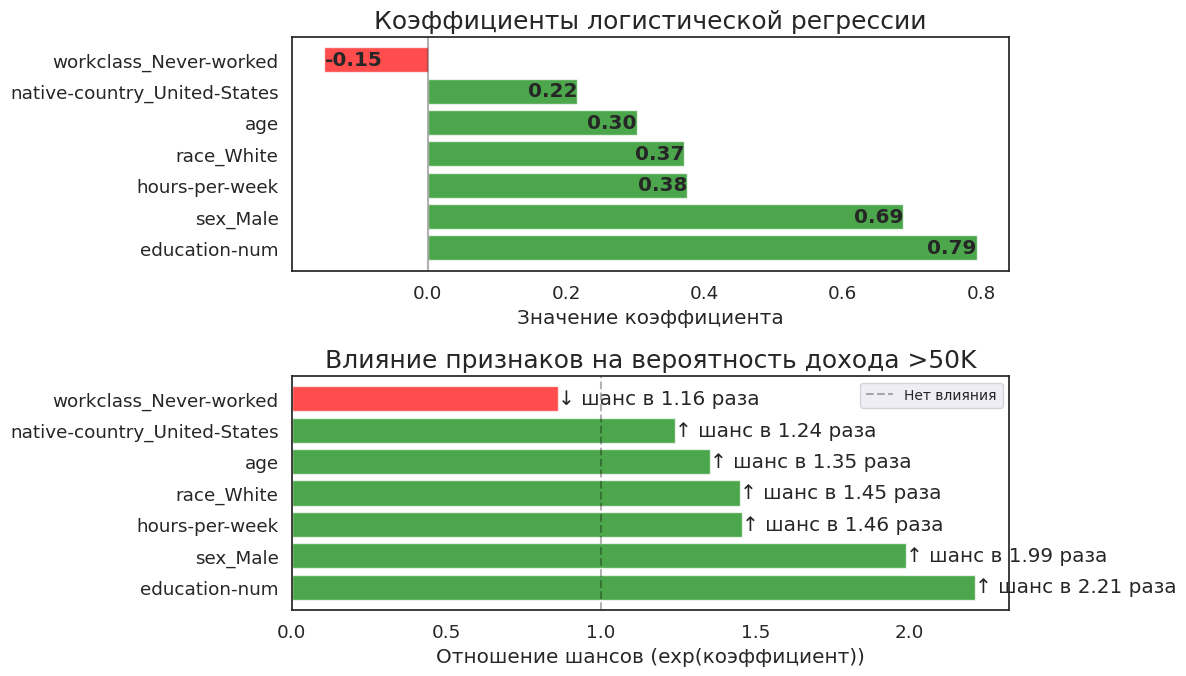

In [27]:
selected_features = [
    "age",
    "education-num",
    "hours-per-week",
    "workclass_Never-worked",
    "sex_Male",
    "race_White",
    "native-country_United-States",
]

selected_indices = [list(all_feature_names).index(f) for f in selected_features]

# Получаем коэффициенты для выбранных признаков
selected_coef = lr_model.coef_[0][selected_indices]
selected_odds = np.exp(selected_coef)

coef_plot_df = pd.DataFrame(
    {"Признак": selected_features, "Коэффициент": selected_coef, "Отношение_шансов": selected_odds}
).sort_values("Коэффициент", ascending=False)

plot_logreg_coefficients(coef_plot_df)

Итак, видим, что:

- Мужчины имеют значительно более высокие шансы получить доход выше 50K – в 2 раза выше, чем женщины

- Каждый дополнительный уровень образования увеличивает шансы приблизительно в 2.21 раза

- Чем больше часов в неделю работает человек, тем выше вероятность дохода >50K. Увеличение на единицу связано с ростом шансов на 1.46 раза

- С возрастом шансы увеличиваются примерно в 1.35 раза за каждый год

- Если человек никогда не работал, его шансы получить высокий доход снижаются, коэффициент отрицательный, шансы уменьшаются в 1.18 раза


Остается вопрос в каком случае данная интерпретация верна? В случае линейной регресии итепретация была верная, когда зависимость между признаком и таргетов линейная. В случае логистической же регресии данная интерпретация будет верна при линейности логита. Рассмотрим поподробнее.

### <span style="display:inline-block;padding:2px 8px;border-radius:999px;background:linear-gradient(135deg, #C7480B 0%, #B52D59 54%, #A617B3 100%);color:#FFFFFF;font-size:0.78em;vertical-align:0.08em;">4</span> <span style="color:inherit;">Предположение о линейности логита</span>

Пусть для некоторого объекта
- $p$ – вероятность принадлежности классу 1
- $(1 - p)$ – вероятность принадлежности классу 0

Логистическая регрессия основана на предположении о **линейной зависимости между признаками и логитом** вероятности принадлежности к классу 1. Математически это выражается следующим соотношением:

$$\log\left(\frac{p}{1-p}\right) = \theta_0 + \theta_1 x_1 + \theta_2 x_2 + \ldots + \theta_d x_d$$

Предположение о линейности означает, что логит вероятности линейно зависит от каждого признака. Это можно проверить, построив зависимость логита от каждого признака.

Если предположение выполняется, то логистическая регрессия будет хорошо работать.
Если нет – могут потребоваться преобразования признаков или более сложные модели.

---

#### <span style="display:inline-block;padding:2px 8px;border-radius:999px;background:linear-gradient(135deg, #C7480B 0%, #B52D59 54%, #A617B3 100%);color:#FFFFFF;font-size:0.78em;vertical-align:0.08em;">4.1</span> <span style="color:inherit;">Линейно разделимые данные</span>

Сгенерируем датасет из двух пересекающихся шарообразных классов

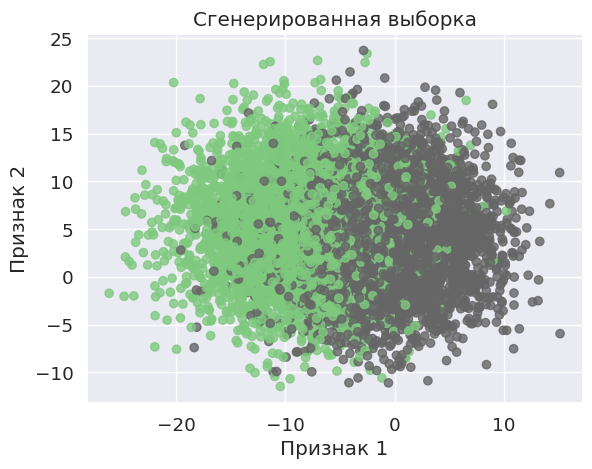

In [28]:
X, y = make_blobs(
    n_samples=10000, n_features=2, centers=2, cluster_std=5.0, random_state=RANDOM_STATE
)

plt.title("Сгенерированная выборка")
plt.scatter(X[:, 0], X[:, 1], c=y, alpha=0.8, cmap="Accent")
plt.xlabel("Признак 1")
plt.ylabel("Признак 2")
plt.show()

Проверим линейность логита по каждому признаку.


> Для этого воспользуемся так называемым ядерным сглаживанием для оценки зависимости $\mathsf{P}(y=1|x)$ от каждого признака.
>
> $$\widehat{\mathsf{P}}(y=1|x) = \frac{\sum_{i=1}^n Y_i \cdot K\left(\frac{x - x_i}{h}\right)}{\sum_{i=1}^n K\left(\frac{x - x_i}{h}\right)}$$
>
> - $K(u)$ – ядро (функция сглаживания). Это симметричная функция, которая определяет, насколько каждое наблюдение $x_i$ влияет на оценку в точке $x$
>
> - $u = \frac{x - x_i}{h}$ – нормированное расстрояние от точки $x_i$ до точки $x$, в которой мы оцениваем
>
> - $h$ – параметр ширины ядра
>
> Чем ближе $x_i$ к $x$, тем больше вес $K(\frac{x - x_i}{h})$. Наблюдения, далекие от $x$, получают очень маленькие или нулевые веса.
>
> *Смысл формулы*: оцениваем вероятность принадлежности к классу 1 в точке $x$ как взвешенное среднее меток всех наблюдений, где веса определяются близостью к точке $x$. Чем ближе $x_i$ к $x$, тем больше вес $K(\frac{x - x_i}{h})$.

In [29]:
def kernel_smooth_logit(
    x: np.ndarray, y: np.ndarray, x_grid: np.ndarray, h: float = 1.0, epsilon: float = 1e-10
) -> Tuple[np.ndarray, np.ndarray]:
    """
    Вычисляет сглаженный логит с помощью ядерного сглаживания.

    Параметры:
    x : np.ndarray, shape (n_samples,)
        Значения признака для вычисления сглаживания.
    y : np.ndarray, shape (n_samples,)
        Целевые переменные (должны содержать 0 и 1).
    x_grid : np.ndarray, shape (n_points,)
        Сетка точек, в которых вычисляется оценка логита.
    h : float, default=1.0
        Ширина ядра (bandwidth) для сглаживания.
    epsilon : float, default=1e-10
        Малое число для регуляризации и избежания численной нестабильности.

    Возвращает:
    x_grid : np.ndarray
        Исходная сетка точек (возвращается для удобства).
    logit_smoothed : np.ndarray
        Сглаженные значения логита в точках сетки.
    """
    # Гауссовское ядро
    kernel = sps.norm(scale=h)

    # Вычисляем значения ядра
    kernel_values = kernel.pdf(x[:, np.newaxis] - x_grid[np.newaxis, :])

    # Ядерная оценка вероятности P(y=1|x)
    numerator = (y[:, np.newaxis] * kernel_values).sum(axis=0)
    denominator = kernel_values.sum(axis=0)

    # Избегаем деления на ноль
    denominator = np.maximum(denominator, epsilon)
    y_est = numerator / denominator

    # Регуляризация для избежания крайних значений
    y_est = np.clip(y_est, epsilon, 1 - epsilon)

    # Преобразование в логит: log(P/(1-P))
    logit_smoothed = np.log(y_est / (1 - y_est))

    return x_grid, logit_smoothed

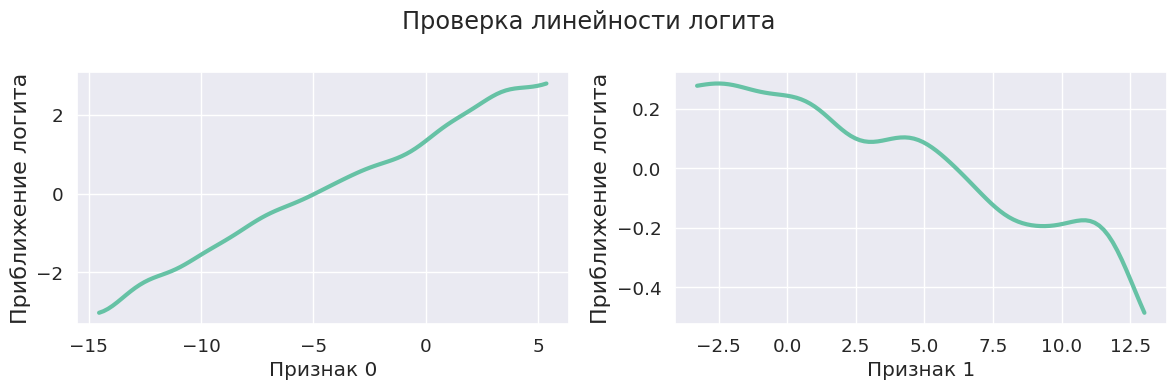

In [30]:
h = 1  # ширина ядра
size = 5000  # проверим линейность на небольшой подвыборке
plot_logit_linearity_check(X, y, h, size, kernel_smooth_logit=kernel_smooth_logit)

Разделим выборку на тестовую и обучающую.

In [31]:
X_train_syntetic, X_test_syntetic, y_train_syntetic, y_test_syntetic = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

Обучим логистическую регрессию и посмотрим на качество предсказаний.

In [32]:
lr = LogisticRegression().fit(X_train_syntetic, y_train_syntetic)
y_pred = lr.predict(X_test_syntetic)
y_pred_proba = lr.predict_proba(X_test_syntetic)[:, 1]

accuracy = accuracy_score(y_test_syntetic, y_pred)
print(f"Точность на тестовой выборке: {accuracy:.4f}")

Точность на тестовой выборке: 0.7635


Точность получилась хорошая.

Посмотрим на визуализации предсказаний модели линейной регрессии.

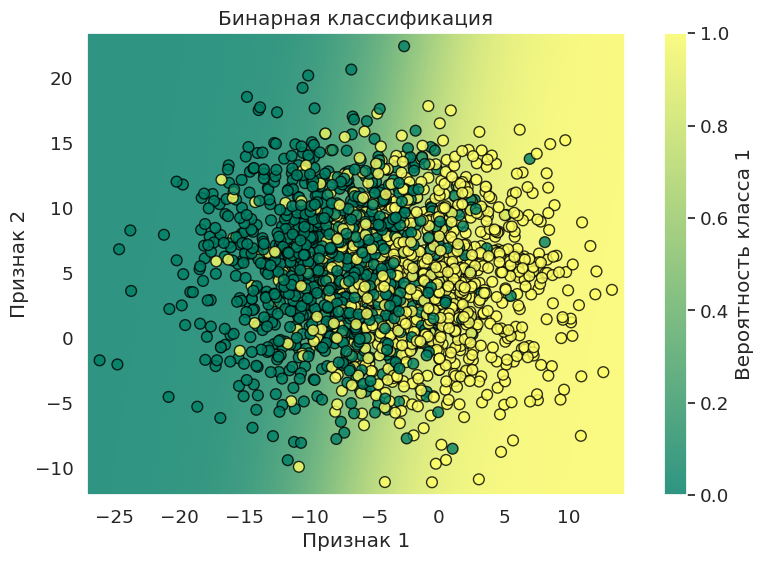

In [33]:
plot_decision_boundary(
    lr,
    X_test_syntetic,
    y_test_syntetic,
    title="Бинарная классификация",
    xlabel="Признак 1",
    ylabel="Признак 2",
)

Видим, что предсказания более уверенные в тех областях, где есть только точки одного класса и менее уверенные на границе классов.

#### <span style="display:inline-block;padding:2px 8px;border-radius:999px;background:linear-gradient(135deg, #C7480B 0%, #B52D59 54%, #A617B3 100%);color:#FFFFFF;font-size:0.78em;vertical-align:0.08em;">4.2</span> <span style="color:inherit;">Более сложная выборка</span>

Сгенерируем выборку, в которой классы не являются линейно-разделимыми, а также добавим к ней фоновый шум из точек разных классов.

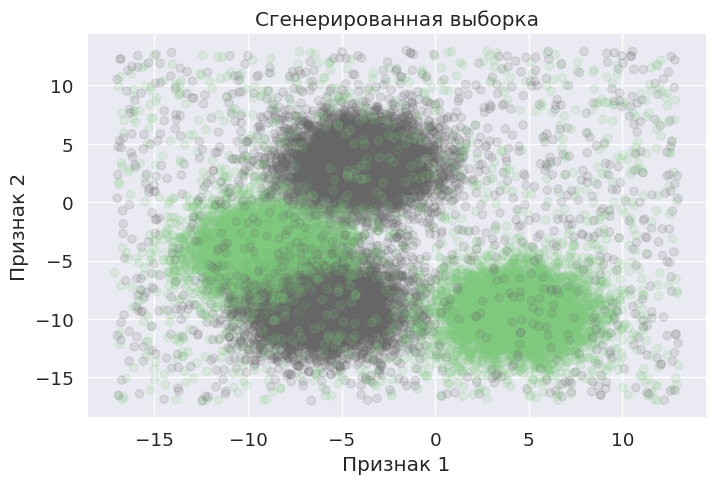

In [34]:
X, y = make_blobs(n_samples=20000, n_features=2, centers=4, cluster_std=2.1, random_state=21)
y = (y >= 2).astype(int)

# Шум
n_noise = 2000
X = np.vstack([X, sps.uniform(loc=-17, scale=30).rvs((n_noise, 2))])
y = np.hstack([y, sps.bernoulli(p=0.5).rvs(n_noise)])

# Посмотрим на выборку
plt.figure(figsize=(8, 5))
plt.title("Сгенерированная выборка")
plt.scatter(X[:, 0], X[:, 1], c=y, alpha=0.15, cmap="Accent")
plt.xlabel("Признак 1")
plt.ylabel("Признак 2")
plt.show()

Проверим, выполнена ли линейность логита по каждому из признаков

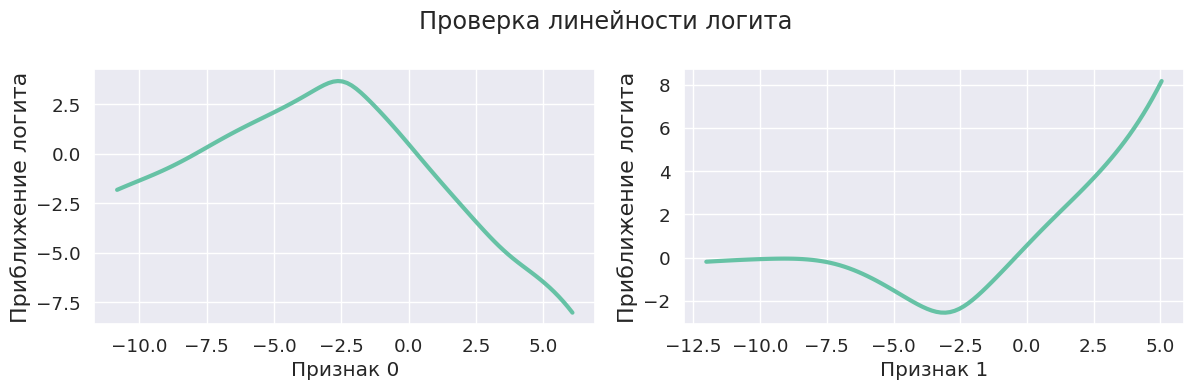

In [35]:
h = 1  # ширина ядра
size = 5000  # проверим линейность на небольшой подвыборке
plot_logit_linearity_check(X, y, h, size, kernel_smooth_logit=kernel_smooth_logit)

Вполне логично, что в этот раз логит нелинеен.

Аналогично разделим выборку на тестовую и обучающую и обучим логистичекую регрессию.

In [36]:
X_train_syntetic, X_test_syntetic, y_train_syntetic, y_test_syntetic = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

lr = LogisticRegression().fit(X_train_syntetic, y_train_syntetic)
y_pred = lr.predict(X_test_syntetic)
y_pred_proba = lr.predict_proba(X_test_syntetic)[:, 1]

accuracy = accuracy_score(y_test_syntetic, y_pred)
print(f"Точность на тестовой выборке: {accuracy:.4f}")

Точность на тестовой выборке: 0.5434


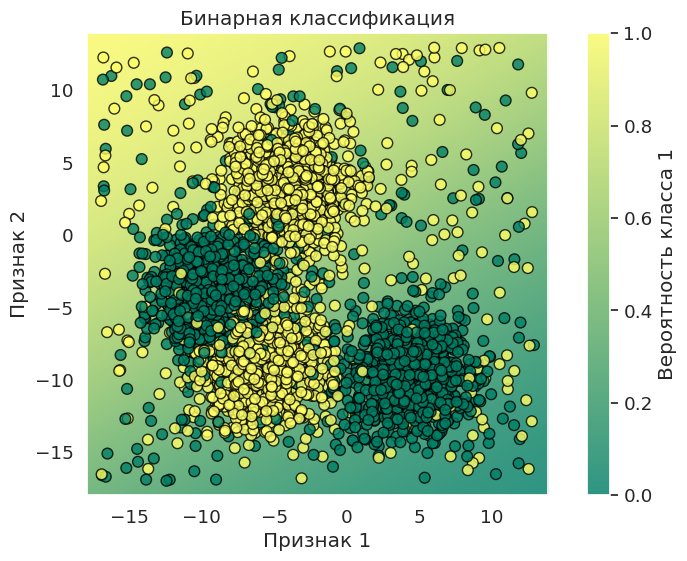

In [37]:
plot_decision_boundary(
    lr,
    X_test_syntetic,
    y_test_syntetic,
    title="Бинарная классификация",
    xlabel="Признак 1",
    ylabel="Признак 2",
)

Предположение о линейности логита не выполняется, поэтому модель логистической регрессии работает на уровне случайного угадывания.

#### <span style="display:inline-block;padding:2px 8px;border-radius:999px;background:linear-gradient(135deg, #C7480B 0%, #B52D59 54%, #A617B3 100%);color:#FFFFFF;font-size:0.78em;vertical-align:0.08em;">4.3</span> <span style="color:inherit;">Проверка линейности логита</span>



Проведем аналогичный по определению линейности логита для первых 4-х признаков нашего датасета.

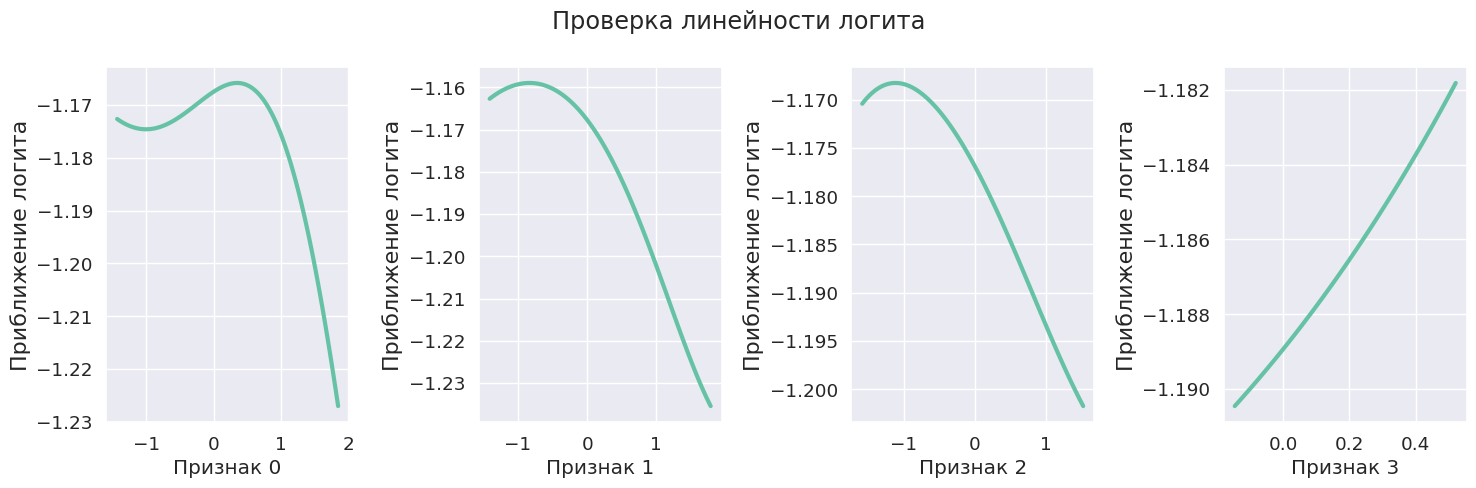

In [38]:
plot_logit_linearity_check(
    X_train_processed[:, :4],
    y_data,
    h,
    size,
    figsize=(15, 5),
    kernel_smooth_logit=kernel_smooth_logit,
)

Можем заметить квадратичную связь первых трех признаков. Добавим квадрат этих признаков в выборку.

In [39]:
features_to_square_train = X_train_processed[:, 0:3]
features_to_square_test = X_test_processed[:, 0:3]

squared_features_test = features_to_square_test**2
squared_features_train = features_to_square_train**2

X_train_processed_new = np.hstack((X_train_processed, squared_features_train))
X_test_processed_new = np.hstack((X_test_processed, squared_features_test))

In [40]:
lr_model = LogisticRegression()
lr_model.fit(X_train_processed_new, y_train)

y_pred = lr_model.predict(X_test_processed_new)

acc = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc:.4f}")

Accuracy: 0.8508


Еще подняли качество. Рассмотрим общую производительность.

In [41]:
benchmark.add_model(
    lr_model,
    "LR with squared features",
    X_train_processed_new,
    X_test_processed_new,
    y_train,
    y_test,
)

display(benchmark.show_table())

Модель 'LR with squared features' успешно добавлена.


,Model,Fit time (s),Predict time (s),Memory (KB),Accuracy
0,Baseline,0.001311,0.000130,0.991211,0.763538
1,kNN,0.002834,1.158658,11600.589844,0.824138
2,Logistic Regression,1.321128,0.002030,1.139648,0.834681
3,LR NaN processed,2.390156,0.008578,1.608398,0.846351
4,LR with squared features,2.285798,0.009235,1.624023,0.850752


### <span style="display:inline-block;padding:2px 8px;border-radius:999px;background:linear-gradient(135deg, #C7480B 0%, #B52D59 54%, #A617B3 100%);color:#FFFFFF;font-size:0.78em;vertical-align:0.08em;">5</span> <span style="color:inherit;">Логистическая регрессия для многоклассовой классификации</span>

В задачах классификации часто встречаются случаи, когда количество классов больше двух:
 * распознавание цифр (уже знакомы MNIST),
 * классификация типов объектов,
 * классификация текстов по категориям,
 * сегментация клиентов и т.д.

Рассмотрим методы расширения логистической регрессии на случай многоклассовой классификации.

#### <span style="display:inline-block;padding:2px 8px;border-radius:999px;background:linear-gradient(135deg, #C7480B 0%, #B52D59 54%, #A617B3 100%);color:#FFFFFF;font-size:0.78em;vertical-align:0.08em;">5.1</span> <span style="color:inherit;">Стратегии в мультиклассовой логистической регрессии</span>

Модель логистической регрессии можно обобщить для случая многоклассовой классификации. Пусть метка класса принимает значения в $K$-элементном множестве $\mathscr{Y} = \{1, ..., K\}$. Параметры модели $\theta$ являются матрицей размерности $K \times d$, где $d$ &mdash; количество признаков.

Введем soft-max функцию: 
$$
\sigma(z) = \big( \sigma_1(z), \dots, \sigma_K(z) \big) = \left( \frac{e^{z_1}}{\sum_{i=1}^K e^{z_i}}, \dots, \frac{e^{z_K}}{\sum_{i=1}^K e^{z_i}} \right).
$$

Из определения ясно, что $\sum\limits_{k=1}^K \sigma_k(z) = 1$. Название функции связано с тем, что самая большая компонента вектора $z$ будет близка к $1$, а все остальные будут малы, но не равны нулю. Таким образом, происходит сглаженное взятие `argmax`.

По аналогии с простой логистической регрессией рассмотрим выборку объектов $x_1, ...,  x_n$, где $x_i = (x_{i1}, \dots, x_{id})^T \in \mathbb{R}^d$, и выборку таргетов $Y_1, ...,  Y_n \in \mathscr{Y}$
Модель логистической регрессии в многоклассовом случае предполагает, что $\mathsf{P}_{\theta}(Y_{i} = k) = \sigma_k(\theta x)$, где $\theta \in \mathbb{R}^{k \times d}$. Тогда обучение модели логистической регрессии в многоклассовом случае выглядит следующим образом:

$$
- \sum_{i=1}^n \sum_{k=1}^K I\{Y_i = k\} \log
    \sigma_k(\theta x_i)
\longrightarrow \min_{\theta}
$$

Обучать эту модель также можно с помощью градиентного спуска.

Кроме того существует другой, более универсальный способ решать задачу многоклассовой классификации. Для этого нужно обучить несколько моделей бинарной классификации, после чего на основании предсказаний по этим моделям вынести окончательный вердикт о принадлежности объекта одному из $K$ классов.

> Можно выделить две популярные стратегии использования бинарных классификаторов для задачи многоклассовой классификации:
>
> * `OvR` (One-vs-Rest, One-vs-All) &mdash; стратегия, при которой каждый из $K$ классификаторов обучается отделять объекты одного класса от объектов всех остальных классов. В качестве предсказания используется тот класс, классификатор которого предсказал наибольшую вероятность среди всех.
>
> * `OvO` (One-vs-One) &mdash; стратегия, при которой каждый из $\cfrac{K(K-1)}{2}$ классификаторов учится разделять объекты пары классов, игнорируя объекты всех остальных классов. Таким образом, каждый классификатор тренируется на подвыборке, состоящей только из двух конкретных классов. На этапе предсказания классификаторы предсказывают метку класса для объекта (именно метку, не вероятность) и для данного объекта выбирается класс, который предсказывался больше всего среди всех классификаторов.

#### <span style="display:inline-block;padding:2px 8px;border-radius:999px;background:linear-gradient(135deg, #C7480B 0%, #B52D59 54%, #A617B3 100%);color:#FFFFFF;font-size:0.78em;vertical-align:0.08em;">5.2</span> <span style="color:inherit;">Пример</span>

В качестве датасета воспользуемся функцией `make_blobs` из `sklearn`. Сгенерируем выборку, разделим на обучающую и тестовую.

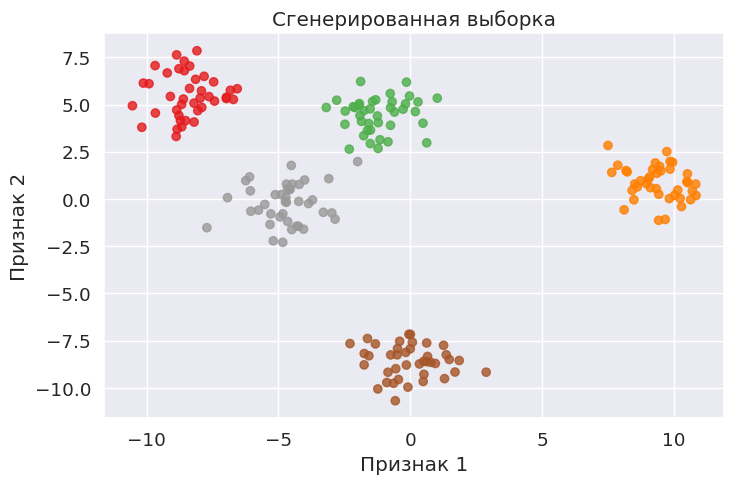

In [42]:
X, y = make_blobs(n_samples=200, centers=5, random_state=RANDOM_STATE)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=RANDOM_STATE)

plt.figure(figsize=(8, 5))
plt.title("Сгенерированная выборка")
plt.scatter(X[:, 0], X[:, 1], c=y, alpha=0.8, cmap="Set1")
plt.xlabel("Признак 1"), plt.ylabel("Признак 2")
plt.show()

Исследуем каждую из стратегий. Для `multinomial`, `OvR` можно воспользоваться стандартным классом `LogisticRegression` из `sklearn` указав соотвествующий параметр [`multi_class`](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html), для `OvO` можно воспользоваться [`OneVsOneClassifier`](https://scikit-learn.org/stable/modules/generated/sklearn.multiclass.OneVsOneClassifier.html).

Заведем три классификатора с различными стратегиями:

In [43]:
ovo_strategy = OneVsOneClassifier(LogisticRegression(random_state=RANDOM_STATE), n_jobs=-1).fit(
    X_train, y_train
)

ovr_strategy = OneVsRestClassifier(LogisticRegression(random_state=RANDOM_STATE)).fit(
    X_train, y_train
)

multinomial = LogisticRegression(random_state=RANDOM_STATE).fit(X_train, y_train)


for clf, strategy in zip([ovo_strategy, ovr_strategy, multinomial], ["OvO", "OvR", "multinomial"]):
    print("Accuracy для {}: {}".format(strategy, accuracy_score(y_test, clf.predict(X_test))))

Accuracy для OvO: 1.0
Accuracy для OvR: 1.0
Accuracy для multinomial: 1.0


Вспомогательные функции для отрисовки графиков:

In [44]:
def scatter_data(X: np.ndarray, y: np.ndarray, clf: Any):
    """
    Отображаем выборку на плоскости.

    Параметры:
    X (np.ndarray): Матрица признаков.
    y (np.ndarray): Таргеты.
    clf (Any): Модель-классификатор.
    """

    colors = "bgryw"
    for i, color in zip(clf.classes_, colors):
        idx = np.where(y == i)
        plt.scatter(X[idx, 0], X[idx, 1], c=color, cmap="Set1", edgecolor="black", s=45)


def plot_decision_plane(X: np.ndarray, y: np.ndarray, clf: Any):
    """
    Строим решающую плоскость классификатора.

    Параметры:
    X (np.ndarray): Матрица признаков.
    y (np.ndarray): Таргеты.
    clf (Any): Модель-классификатор.
    """

    # создаем сетку для построения графика
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02), np.arange(y_min, y_max, 0.02))

    # получаем предсказания для сетки
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

    plt.contourf(xx, yy, Z, cmap="viridis")
    scatter_data(X, y, clf)
    plt.xticks([])
    plt.yticks([])

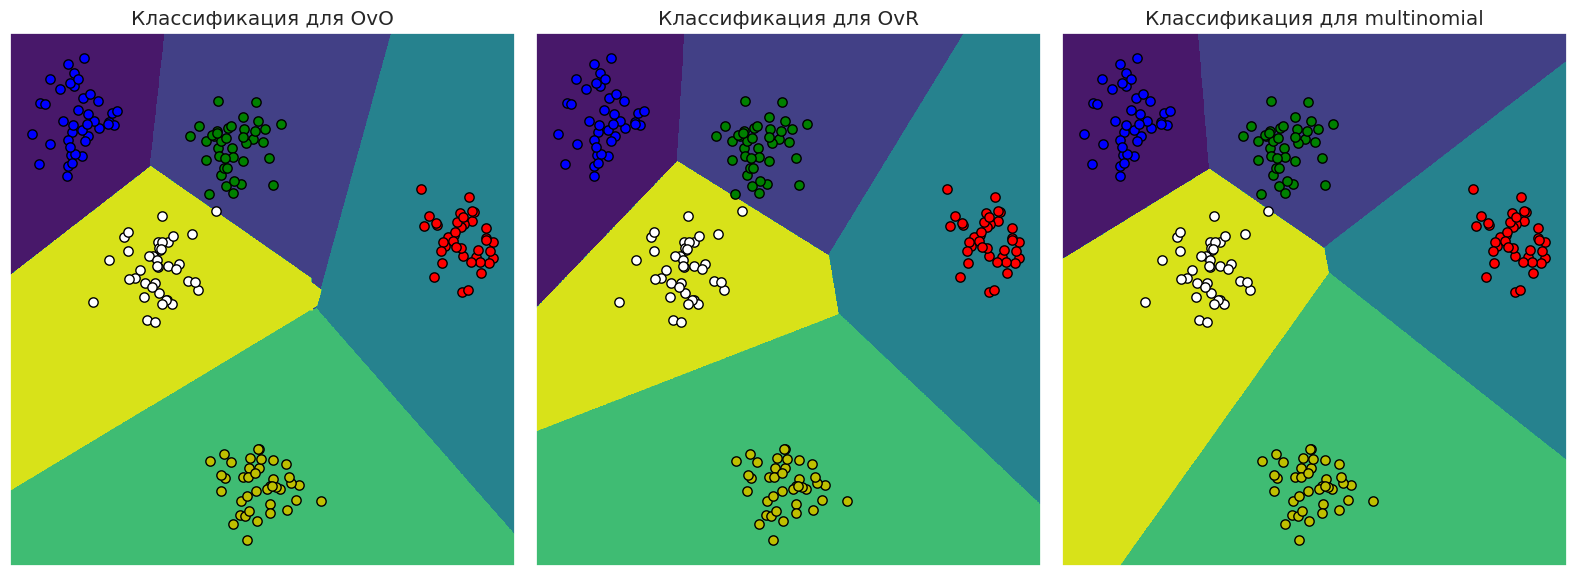

In [45]:
plt.figure(figsize=(16, 6))

for ind, (clf, strategy) in enumerate(
    zip([ovo_strategy, ovr_strategy, multinomial], ["OvO", "OvR", "multinomial"])
):

    plt.subplot(1, 3, ind + 1)
    plt.title("Классификация для {}".format(strategy))
    plot_decision_plane(X, y, clf)

plt.tight_layout()

Для стратегий `OvO` и `OvR` параметры моделей являются коэфициентами прямых. Построим их только для стратегии `OvR`, так как для `OvO` получится слишком нагроможденная картинка:

In [46]:
def plot_hyperplanes(X: np.ndarray, y: np.ndarray, clf: Any):
    """
    Строим разделяющие гиперплоскости для стратегии One-vs-Rest (OvR).

    Параметры:
    X (np.ndarray): Матрица признаков.
    y (np.ndarray): Таргеты.
    clf (Any): Модель-классификатор.
    """

    scatter_data(X, y, clf)
    xmin, xmax = plt.xlim()

    # Извлекаем коэффициенты
    coef = np.array([est.coef_.ravel() for est in clf.estimators_])
    intercept = np.array([est.intercept_.ravel() for est in clf.estimators_]).flatten()

    # Функция для вычисления Y-координаты линии: w0*x + w1*y + b = 0 -> y = -(w0*x + b)/w1
    # index - это номер строки в массиве coef_
    def line(x0, index):
        return (-(x0 * coef[index, 0]) - intercept[index]) / coef[index, 1]

    colors = "bgryw"

    # Проходим по всем классам.
    for index, (cls_label, color) in enumerate(zip(clf.classes_, colors)):
        plt.plot(
            [xmin, xmax],
            [line(xmin, index), line(xmax, index)],
            ls="--",
            color=color,
            lw=3,
        )

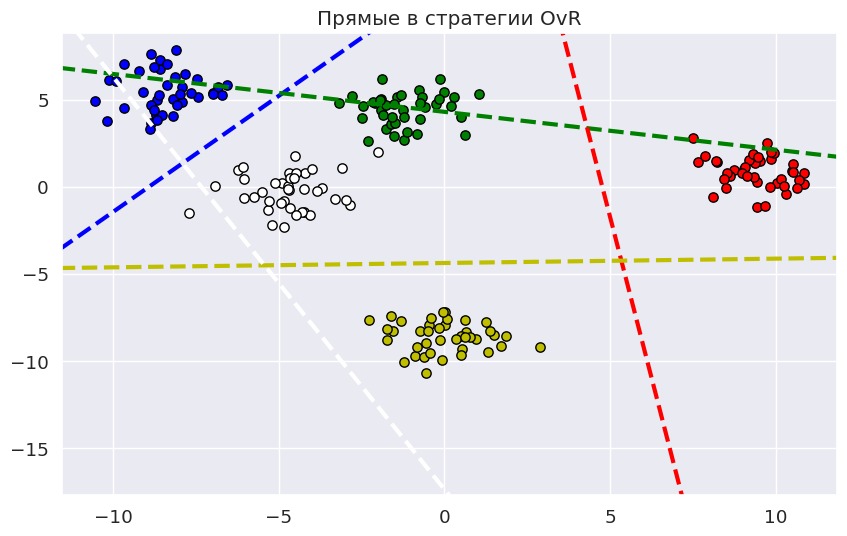

In [47]:
plt.figure(figsize=(10, 6))
plt.title("Прямые в стратегии OvR")
plot_hyperplanes(X, y, ovr_strategy)
plt.xlim((X[:, 0].min() - 1, X[:, 0].max() + 1))
plt.ylim((X[:, 1].min() - 7, X[:, 1].max() + 1));

Видим, что для красного, синего, желтого, зеленого классов полученная прямая хорошо отделяет их от всех остальных классов.

**`OvO`**

* *плюсы*: обучается на более-менее сбалансированных данных (так как рассматривается только два класса). Каждый классификатор обучается на подвыборке из двух классов, следовательно обучение одного классификатора происходит быстрее, чем в `OvR`;

* *минусы*: ${O\left(n_{classes}^2\right)}$ классификаторов, что долго; страдает от неоднозначности, когда в точке у двух классов одинаковое количество голосов.

**`OvR`**

* *плюсы*: ${O\left(n_{classes}\right)}$ классификаторов;

* *минусы*: каждый классификатор обучается на несбалансированной выборке; страдает от неоднозначности, когда в точке у двух классов одинаковое количество голосов.

**`multinomial`**

* *плюсы*: один классификатор (хоть параметров столько же, сколько и в `OvR`);

* *минусы*: задача оптимизации, которую решает данная стратегия, уже гораздо сложнее, чем при бинарной классификации, поэтому обычно требуется чуть больше времени для сходимости.

<div style="box-sizing:border-box;max-width:100%;margin-top:42px;padding:18px 0 4px;border-top:1px solid rgba(127, 127, 127, 0.28);color:inherit;font-size:0.9em;line-height:1.5;"><img src="https://thetahat.ru/images/logo_thetahat.png" alt="ThetaHat" style="display:block!important;width:34px!important;max-width:34px!important;height:auto!important;margin:0 0 9px 0!important;padding:0!important;">© 2026 команда <a href="https://thetahat.ru/" style="color:inherit;font-weight:750;text-decoration:underline;text-decoration-color:#F13A3F;text-underline-offset:3px;">ThetaHat</a> для ШАД</div>